# Análisis Exploratorio de Datos (EDA)

### Objetivos del notebook:

* Suministrar contexto sobre el problema y la naturaleza de los datos disponibles.
* Evaluar la integridad del dataset y definir estrategias de limpieza/tratamiento.
* Establecer la relación entre las variables independientes y la variable objetivo (`fraude`).
* Identificar y documentar las variables que deben ser descartadas del *pipeline* final debido a
 problemas de calidad o su relación con la variable objetivo.

In [1]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

## Configuración del notebook

In [2]:
# Constantes usadas en el notebook
ROOT = "../"
DATA = os.path.join(ROOT, "data")
paleta_color = "pastel6"

In [3]:
# Lectura del dataset de transacciones
transactions = pd.read_csv(f"{DATA}/dataset.csv", parse_dates=["fecha"])
transactions.head(3)

,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.6812,50084.12,50.0,0.000000,20.0,AR,1,cat_d26ab52,0.365475,2479.0,952.0,1,NaN,Y,2020-03-20 09:28:19,57.63,100,0
1,4,0.6694,66005.49,0.0,0.000000,2.0,AR,1,cat_ea962fb,0.612728,2603.0,105.0,1,Y,Y,2020-03-09 13:58:28,40.19,25,0
2,4,0.4718,7059.05,4.0,0.463488,92.0,BR,25,cat_4c2544e,0.651835,2153.0,249.0,1,Y,Y,2020-04-08 12:25:55,5.77,23,0


## Análisis de Calidad de dataset

In [4]:
# 1.1 Información general del dataset
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   a       150000 non-null  int64         
 1   b       137016 non-null  float64       
 2   c       137016 non-null  float64       
 3   d       149635 non-null  float64       
 4   e       150000 non-null  float64       
 5   f       149989 non-null  float64       
 6   g       149806 non-null  str           
 7   h       150000 non-null  int64         
 8   j       150000 non-null  str           
 9   k       150000 non-null  float64       
 10  l       149989 non-null  float64       
 11  m       149635 non-null  float64       
 12  n       150000 non-null  int64         
 13  o       41143 non-null   str           
 14  p       150000 non-null  str           
 15  fecha   150000 non-null  datetime64[us]
 16  monto   150000 non-null  float64       
 17  score   150000 non-null  int64         


In [5]:
# 1.2 Estadísticas descriptivas del dataset
print("### Estadísticas descriptivas para variables numéricas: ###")
display(transactions.describe(include='number').T.round(2))

print("### Estadísticas descriptivas para variables categóricas: ###")
display(transactions.describe(include='str').T)

### Estadísticas descriptivas para variables numéricas: ###


,count,mean,std,min,25%,50%,75%,max
a,150000.0,3.71,0.75,1.00,4.00,4.00,4.00,4.00
b,137016.0,0.73,0.13,0.00,0.68,0.76,0.81,1.00
c,137016.0,260445.11,846436.14,0.16,9679.91,43711.66,145443.63,13878743.71
d,149635.0,21.68,20.06,0.00,2.00,14.00,50.00,50.00
e,150000.0,0.22,2.43,0.00,0.00,0.10,0.28,833.33
f,149989.0,51.17,709.47,-5.00,1.00,8.00,33.00,145274.00
h,150000.0,14.19,14.16,0.00,3.00,9.00,21.00,58.00
k,150000.0,0.50,0.29,0.00,0.25,0.50,0.75,1.00
l,149989.0,2305.41,1712.38,0.00,910.00,1937.00,3445.00,7544.00
m,149635.0,299.97,321.08,0.00,42.00,193.00,459.00,2225.00


### Estadísticas descriptivas para variables categóricas: ###


,count,unique,top,freq
g,149806,51,BR,111628
j,150000,8324,cat_43b9c10,2331
o,41143,2,Y,24091
p,150000,2,Y,83129


**Observaciones:**
* `f` tiene valores negativos (mínimo -5), que podrían ser códigos especiales. Además su valores máximos estan muy por encima de su mediana (cola larga).
* `d` tiene como máximo 50 y al menos el 25% de los registros en ese valor.
* `c`, `e` también tienen máximos muy lejos de su mediana (colas largas).
* `j` tiene 8,324 categorías y `g` 51 países, con Brasil como el más frecuente.

In [6]:
# 1.3 Cantidad de variables explicativas (sin target ni la fecha)
features = transactions.drop(columns=['fraude', 'fecha'])
print(f"Variables numéricas: {features.select_dtypes(include='number').shape[1]}")
print(f"Variables categóricas: {features.select_dtypes(include='str').shape[1]}")
print(f"Numéricas con pocos valores (posibles categóricas): {[c for c in features.select_dtypes(include='number') if features[c].nunique() <= 10]}")

Variables numéricas: 13
Variables categóricas: 4
Numéricas con pocos valores (posibles categóricas): ['a', 'n']


In [7]:
# Valores únicos de 'a' y 'n' (posibles categóricas)
display(features['a'].value_counts(dropna=False))
display(features['n'].value_counts(dropna=False))

a
4    128579
2     14378
1      4195
3      2848
Name: count, dtype: int64

n
1    135353
0     14647
Name: count, dtype: int64

**Decisión:** 

`a` se trata como una variable categórica nominal y `n` se tratan como una variable binaria.

In [8]:
# 2.1 Distribución de la variable objetivo (target): por cantidad y por monto
resumen_target = transactions.groupby('fraude')['monto'].agg(transacciones='size', monto_total='sum')
resumen_target['% transacciones'] = resumen_target['transacciones'] / resumen_target['transacciones'].sum() * 100
resumen_target['% monto'] = resumen_target['monto_total'] / resumen_target['monto_total'].sum() * 100
resumen_target.round(2)


,transacciones,monto_total,% transacciones,% monto
fraude,,,,
0,142500,5981199.00,95.0,91.62
1,7500,547271.12,5.0,8.38


**Observación:** 

* El 5% de las transacciones son fraude (desbalance de clases), pero representan el 8.4% del monto total, así que los fraudes suelen ser de montos más altos.

**Decisión:** 
* El modelo se evalúa con las siguientes métricas: *recall, precision y false positive rate*. Se excluye el accuracy por el desbalance de clases.
* Se evaluará `class_weight` como alternativa al desbalance de clases, considerando que penaliza más los errores sobre la clase minoritaria `fraude`.


In [9]:
# 3.1 Valores faltantes y tasa de fraude con ellos
tasa_fraude_nulo = {c: transactions.loc[transactions[c].isna(), 'fraude'].mean() * 100 for c in transactions.columns}

null_summary = pd.DataFrame({
    'cantidad faltantes': transactions.isna().sum(),
    'porcentaje faltantes': transactions.isna().mean() * 100,
    'tasa fraude en nulos (%)': pd.Series(tasa_fraude_nulo),
}).round(2)

null_summary = null_summary[null_summary['cantidad faltantes'] > 0].sort_values('cantidad faltantes', ascending=False)
null_summary


,cantidad faltantes,porcentaje faltantes,tasa fraude en nulos (%)
o,108857,72.57,2.05
b,12984,8.66,6.38
c,12984,8.66,6.38
d,365,0.24,7.95
m,365,0.24,7.95
g,194,0.13,7.73
f,11,0.01,0.00
l,11,0.01,0.00


In [10]:
# 3.2 ¿Los nulos de b/c y d/m están en las mismas filas?
for x, y in [('b', 'c'), ('d', 'm')]:
    print(f"'{x}' y '{y}' tienen nulos en las mismas filas: {transactions[x].isna().equals(transactions[y].isna())}")

'b' y 'c' tienen nulos en las mismas filas: True
'd' y 'm' tienen nulos en las mismas filas: True


**Observaciones:** 

* Excepto `o`, todas las variables tienen menos de 9% de nulos. 
* Si bien `o` tiene 72.6% de nulos, el % de fraude de estas transacciones es 2.05% (menor al 5% del dataset). La ausencia del dato es una señal de menor riesgo y por tanto no se descarta la variable por su % de nulos. 
* En `b/c` ocurre lo contrario: el % de fraude en los nulos es mayor (6.38% frente a 5%), sobre 12.984 registros. Que falte el dato es una señal de mayor riesgo.
* En `d/m` y `g` la tasa también es mayor (7.9% y 7.7%), pero con tan pocos registros (menos de 400) no es una señal concluyente.
* Los nulos de `b/c` y `d/m` están en las mismas filas, lo que sugiere que cada par proviene de la misma fuente de datos.
* `f` y `l` tienen solo 11 nulos, muy pocos para concluir algo de su 0% de fraude.

**Decisión:** 

* Teniendo en cuenta que el modelo desplegado debe tener la capacidad de decidir sobre transacciones incompletas y que los registros nulos son informativos (señal con respecto al % fraude) se opta por las siguientes estrategias:
    * Variables numéricas (`b/c`, `d/m`, `f/l`): se conservan los nulos sin imputar. Algoritmos como LightGBM manejan de forma nativa los nulos y pueden aprovechar esta ausencia directamente en sus particiones, conservando la señal detectada.
    *  `o` y `g` (categóricas): el nulo se trata como una categoría más ("sin_registro").

In [11]:
# 4. Valores sospechosos: negativos en numéricas y strings tipo "unknown" en categóricas
num_cols = transactions.select_dtypes(include='number').columns
negativos = (transactions[num_cols] < 0).sum()
print("Columnas con valores negativos:")
print(negativos[negativos > 0])

cat_cols = transactions.select_dtypes(include='str').columns
strings_sospechosos = ['unknown', 'n/a', 'nan', 'null', 'otros', 'other', '', 'na']
for col in cat_cols:
    conteo = transactions[col].str.lower().isin(strings_sospechosos).sum()
    if conteo > 0:
        print(f"'{col}': {conteo} registros sospechosos")


Columnas con valores negativos:
f    1277
dtype: int64


In [12]:
# Verificación de la distribución de valores negativos en la columna 'f'
print("\nDistribución de negativos en 'f':")
print(transactions.loc[transactions['f'] < 0, 'f'].value_counts().sort_index())
print("\nTasa de fraude (%) según f < 0:")
print(transactions.groupby(transactions['f'] < 0)['fraude'].mean().mul(100).round(2))


Distribución de negativos en 'f':
f
-5.0      1
-4.0      6
-3.0     58
-2.0    335
-1.0    877
Name: count, dtype: int64

Tasa de fraude (%) según f < 0:
f
False    4.97
True     8.77
Name: fraude, dtype: float64


**Observaciones:** 

* `f` es la única variable con negativos (1,277 registros, casi todos -1 y -2). Las transacciones con `f < 0` tienen 8.8% de fraude, contra 5.0% en el resto.
* No hay variables categóricas con valores tipo "unknown"

**Decisión:** 

* Sin diccionario de datos no se puede saber si los valores negativos de `f` son errores o códigos especiales. 
* Se conservan sin modificar: al ser una variable numérica, algoritmos basados en arboles pueden aislarlos con un corte en `f < 0` si aportan información.


In [13]:
# 5. Identificación de duplicados exactos (toda la fila es idéntica)
duplicados_exactos = transactions.duplicated().sum()
print(f"Duplicados exactos en el dataset: {duplicados_exactos}")

Duplicados exactos en el dataset: 0


In [14]:
# 6. Cardinalidad por columna
unique_values_summary = pd.DataFrame({
    'tipo de dato': transactions.dtypes,
    'cantidad unicos': transactions.nunique(),
    'porcentaje unicos': transactions.nunique() / len(transactions) * 100,
    'valor más frecuente': transactions.apply(lambda s: s.value_counts().index[0]),
    '% valor más frecuente': transactions.apply(lambda s: s.value_counts(normalize=True).iloc[0] * 100),
}).round(2).sort_values('cantidad unicos', ascending=False)

unique_values_summary


,tipo de dato,cantidad unicos,porcentaje unicos,valor más frecuente,% valor más frecuente
k,float64,150000,100.00,0.365475,0.00
fecha,datetime64[us],145813,97.21,2020-03-19 15:30:23,0.00
c,float64,135090,90.06,5.55,0.01
e,float64,43208,28.81,0.0,43.37
monto,float64,17831,11.89,23.63,0.16
j,str,8324,5.55,cat_43b9c10,1.55
b,float64,7672,5.11,1.0,1.32
l,float64,7297,4.86,0.0,1.35
m,float64,1793,1.20,0.0,10.62
f,float64,1338,0.89,0.0,16.93


In [15]:
# 6.1 Efecto de agrupar categorías poco frecuentes en "otros"
resumen = []
for col in ['g', 'j']:
    conteo = transactions[col].value_counts()
    for umbral in [20, 50, 100]:
        frecuentes = conteo[conteo >= umbral].index
        es_otros = ~transactions[col].isin(frecuentes) & transactions[col].notna()
        resumen.append({
            'columna': col,
            'umbral (mín. registros)': umbral,
            'categorías conservadas': len(frecuentes),
            'filas en OTROS': es_otros.sum(),
            '% filas en OTROS': es_otros.mean() * 100,
            'tasa fraude en OTROS (%)': transactions.loc[es_otros, 'fraude'].mean() * 100,
        })

print(f"Tasa de fraude global: {transactions['fraude'].mean() * 100:.2f}%")
pd.DataFrame(resumen).round(2)


Tasa de fraude global: 5.00%


,columna,umbral (mín. registros),categorías conservadas,filas en OTROS,% filas en OTROS,tasa fraude en OTROS (%)
0,g,20,10,131,0.09,11.45
1,g,50,9,174,0.12,8.62
2,g,100,6,380,0.25,7.11
3,j,20,1400,30951,20.63,3.53
4,j,50,615,55028,36.69,3.87
5,j,100,271,78715,52.48,4.29


**Observaciones:**
* `k` tiene un valor distinto en cada fila, lo que la hace parecer un identificador.
* `e` vale 0 en el 43% de los registros.
* Agrupar las categorías con menos de 20 registros deja el grupo "otros" con el 20.6% de las filas en `j` y menos del 0.3% en `g`. En ambos casos la tasa de fraude de "OTROS" se ubica por encima del 5% global, aunque en `g` el grupo es demasiado pequeño para concluir que la diferencia sea real.

**Decisión:** 
* `k` es candidata a descartar, pendiente de confirmar en el análisis exploratorio. 
* Se usa el umbral de 20 registros para `j` y `g`. La lista de categorías frecuentes se calcula únicamente con los datos de entrenamiento, para no filtrar información del conjunto de evaluación.

In [16]:
# 7. Revisión de la ventana temporal
fecha_min = transactions['fecha'].min()
fecha_max = transactions['fecha'].max()
dias_totales = (fecha_max - fecha_min).days
print(f"Ventana: {fecha_min} a {fecha_max} ({(fecha_max - fecha_min).days} días)")

# Tasa de fraude por semana
semanal = transactions.groupby(transactions['fecha'].dt.to_period('W'))['fraude'].agg(transacciones='size', tasa_fraude='mean')
semanal['tasa_fraude'] = (semanal['tasa_fraude'] * 100).round(2)
semanal

Ventana: 2020-03-08 00:02:15 a 2020-04-21 23:59:56 (44 días)


,transacciones,tasa_fraude
fecha,,
2020-03-02/2020-03-08,2838,4.37
2020-03-09/2020-03-15,24523,4.83
2020-03-16/2020-03-22,25199,4.56
2020-03-23/2020-03-29,20069,5.69
2020-03-30/2020-04-05,17434,5.78
2020-04-06/2020-04-12,24443,5.41
2020-04-13/2020-04-19,25332,4.29
2020-04-20/2020-04-26,10162,4.76


**Observación:** 
* Los datos cubren 44 días (08-mar a 21-abr de 2020). La tasa semanal de fraude varía entre 4.3% y 5.8%. La primera y la última semana están incompletas.

**Decisión:** 
* train, val y test se separan por fecha (entrenar con las semanas más antiguas y evaluar con las más recientes), garantizando que los cortes respeten semanas completas. Así se simula el uso real del modelo, que decide sobre transacciones futuras, y se evita que información del periodo evaluado se filtre al entrenamiento.

### Recomendaciones para el modelado

Las decisiones justificadas arriba se resumen así:

| Aspecto | Decisión |
|---|---|
| Nulos numéricos (`b/c`, `d/m`, `f/l`) | Se conservan sin imputar |
| Nulos categóricos (`o`, `g`) | Categoría "sin_registro" |
| Negativos en `f` | Se conservan sin modificar |
| Alta cardinalidad (`j`, `g`) | Categorías con <20 registros a "otros" |
| `a`, `n` | Categórica nominal y binaria |
| `k` | Candidata a descartar, pendiente de confirmar |
| Partición | Por fecha (train/val/test), respetando semanas completas |
| Métricas | Recall, precision y FPR (se excluye accuracy) |

Y tres decisiones que se derivan del diagnóstico:

* **Modelo: LightGBM.** Maneja los nulos de forma nativa, que es justo lo que este dataset necesita; acepta categóricas sin codificación previa; y no se ve afectado por las colas largas de `c`, `e`, `f` y `monto`.
* **Categóricas (`g`, `o`, `p`, `a`, `j`):** se pasan como categóricas nativas, sin codificación previa.
* **Colas largas:** no se recortan ni se transforman, por la misma razón anterior.


In [17]:
######### Aplicación de recomendaciones de limpieza y transformación de datos #########

df = transactions.copy()

df[["o", "g"]] = df[['o', 'g']].fillna("sin_registro")
df[["a", "g", "j", "o", "p"]] = df[["a", "g", "j", "o", "p"]].astype('category')

df.dtypes.value_counts()

float64           9
int64             4
category          1
category          1
category          1
category          1
category          1
datetime64[us]    1
Name: count, dtype: int64

## Análisis exploratorio

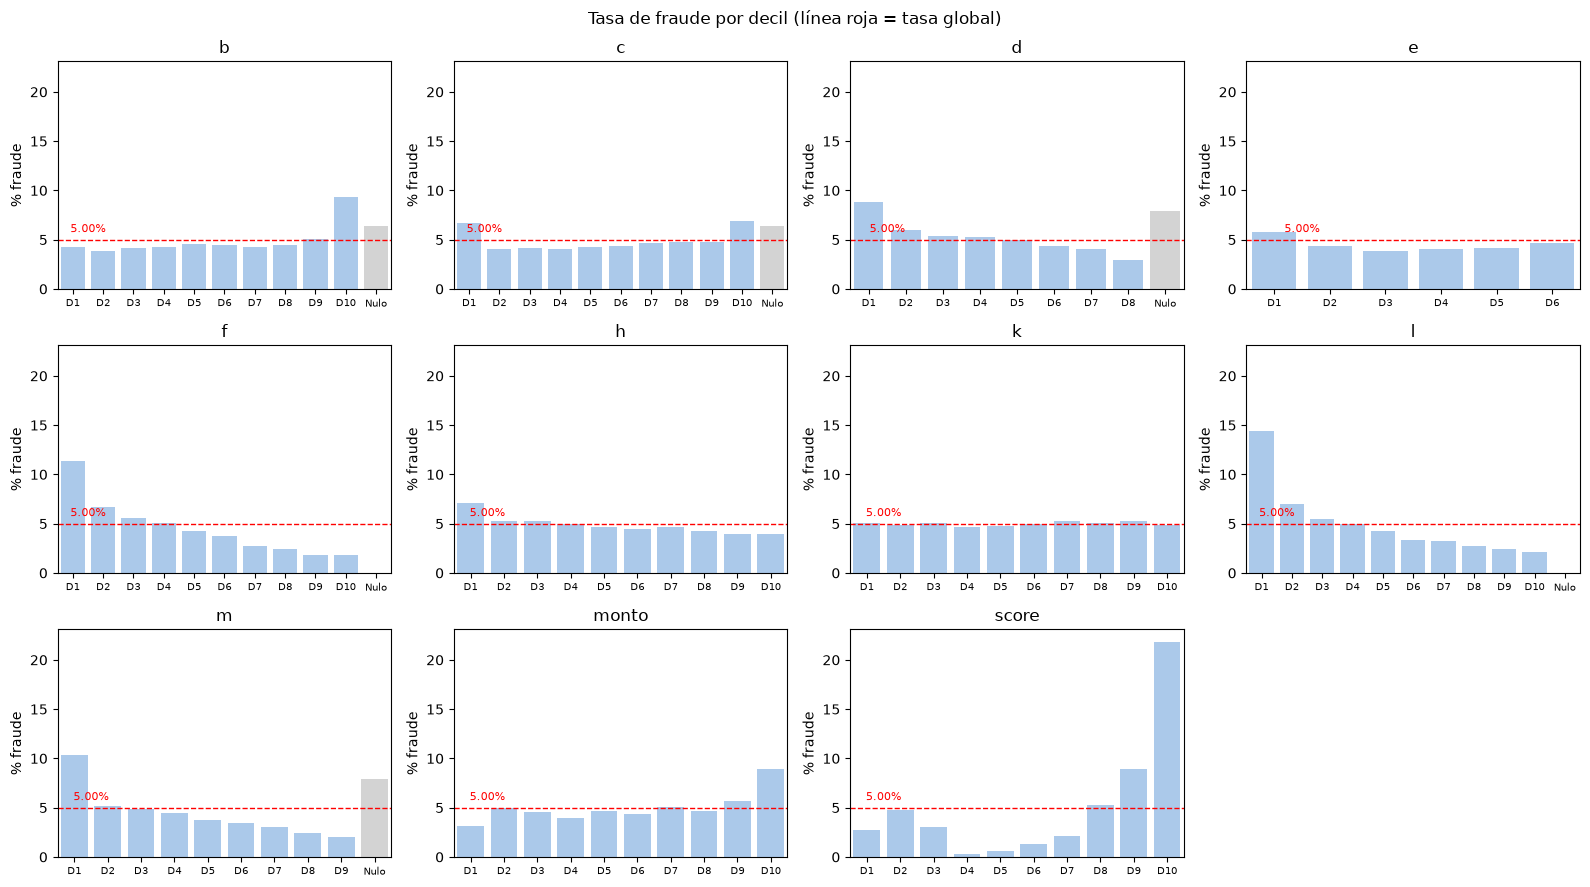

In [18]:
# 1. Tasa de fraude por decil (los nulos van como grupo aparte)
num_cols = ['b', 'c', 'd', 'e', 'f', 'h', 'k', 'l', 'm', 'monto', 'score']
tasa_global = df['fraude'].mean() * 100

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, col in zip(axes.flat, num_cols):
    tramos = pd.qcut(df[col], 10, labels=False, duplicates='drop')
    grupo = tramos.apply(lambda i: f"D{int(i) + 1}" if pd.notna(i) else 'Nulo')
    tasa = df.groupby(grupo, observed=True)['fraude'].mean() * 100

    orden = sorted([g for g in tasa.index if g != 'Nulo'], key=lambda g: int(g[1:]))
    orden += ['Nulo'] if 'Nulo' in tasa.index else []
    colores = ['lightgray' if g == 'Nulo' else sns.color_palette(paleta_color)[0] for g in orden]

    sns.barplot(x=orden, y=tasa[orden].values, ax=ax, hue=orden, palette=colores, legend=False)
    ax.axhline(tasa_global, color='red', ls='--', lw=1)
    ax.text(0.5, tasa_global + 0.5, f"{tasa_global:.2f}%", color='red', ha='center', va='bottom', fontsize=8)
    ax.set_title(col)
    ax.set_ylabel('% fraude')
    ax.set_xlabel('')
    ax.set_ylim(0, 22 * 1.05)
    ax.tick_params(axis='x', labelsize=7)

for ax in axes.flat[len(num_cols):]:
    ax.axis('off')

fig.suptitle('Tasa de fraude por decil (línea roja = tasa global)')
fig.tight_layout()


In [21]:
# 1.1 Tasa de fraude por decil (%)
tabla_decil = pd.DataFrame({
    col: df.groupby(pd.qcut(df[col], 10, labels=False, duplicates='drop'), observed=True)['fraude'].mean() * 100
    for col in num_cols
}).T.round(2)
tabla_decil.columns = [f"D{int(c) + 1}" for c in tabla_decil.columns]
display(tabla_decil)


,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10
b,4.24,3.87,4.12,4.28,4.58,4.44,4.26,4.50,5.11,9.30
c,6.71,4.08,4.12,4.08,4.26,4.40,4.61,4.74,4.77,6.93
d,8.83,5.99,5.39,5.31,4.92,4.35,4.04,2.92,NaN,NaN
e,5.78,4.35,3.90,4.06,4.15,4.65,NaN,NaN,NaN,NaN
f,11.37,6.71,5.56,5.09,4.24,3.74,2.72,2.43,1.86,1.80
h,7.12,5.25,5.29,4.96,4.65,4.46,4.67,4.29,3.99,3.97
k,5.07,4.88,5.10,4.68,4.80,4.99,5.23,5.09,5.28,4.87
l,14.45,7.00,5.43,4.95,4.28,3.31,3.27,2.76,2.42,2.13
m,10.31,5.19,4.88,4.50,3.73,3.48,3.05,2.39,2.04,NaN
monto,3.12,4.92,4.57,3.97,4.66,4.41,5.11,4.63,5.73,8.89


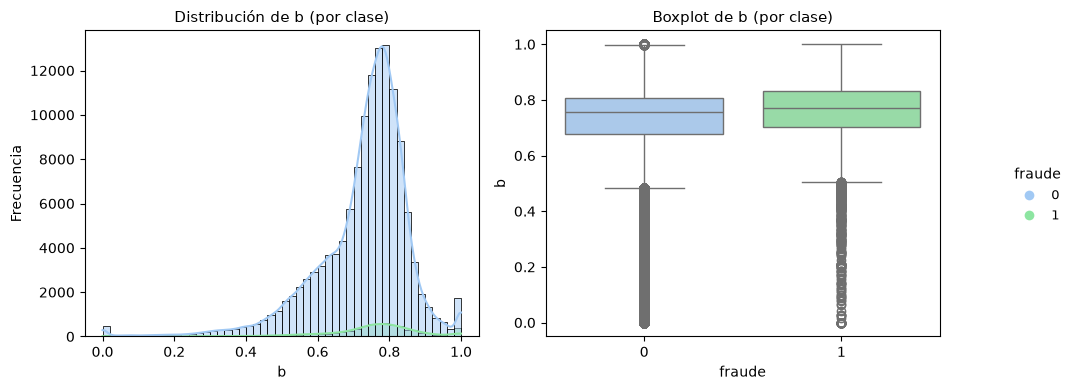

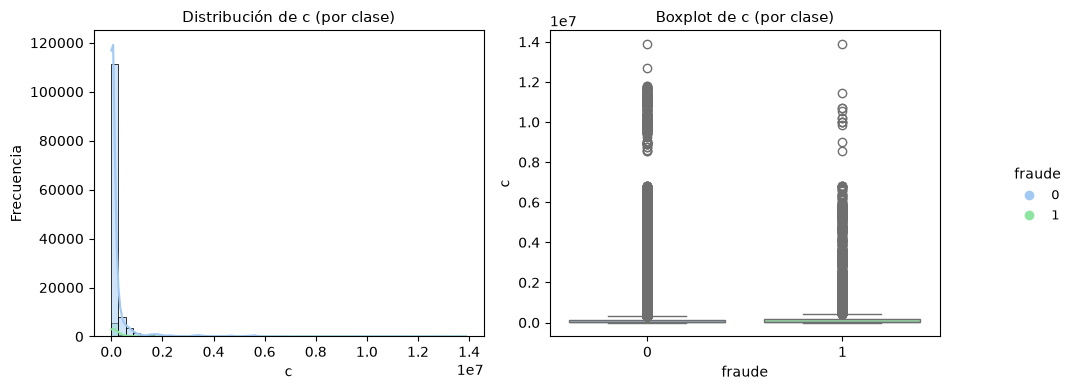

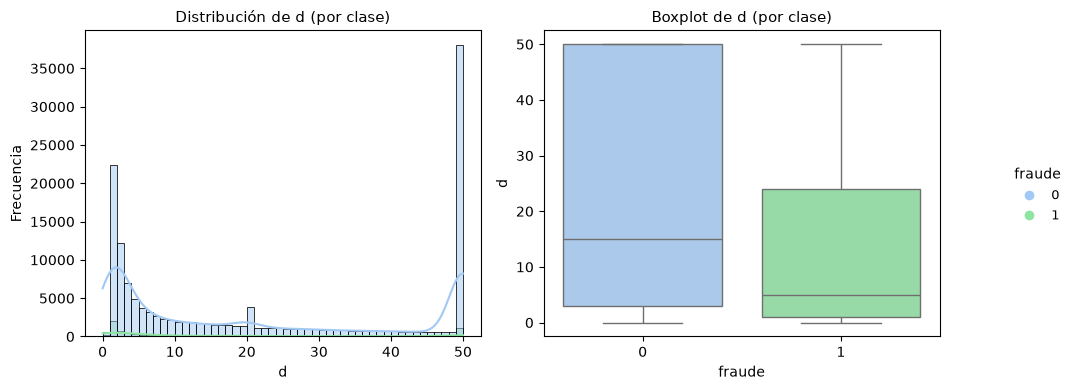

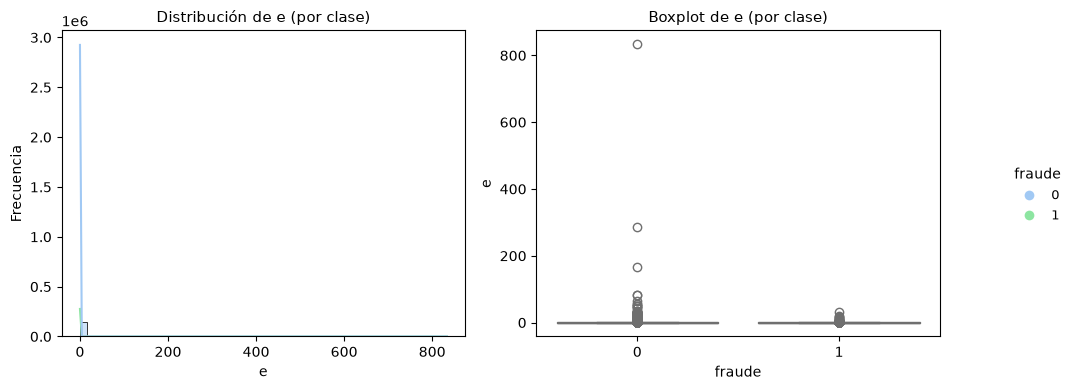

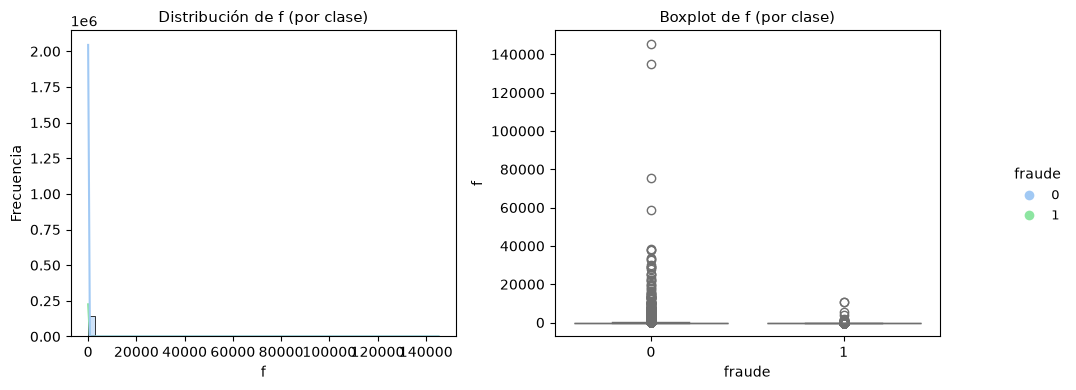

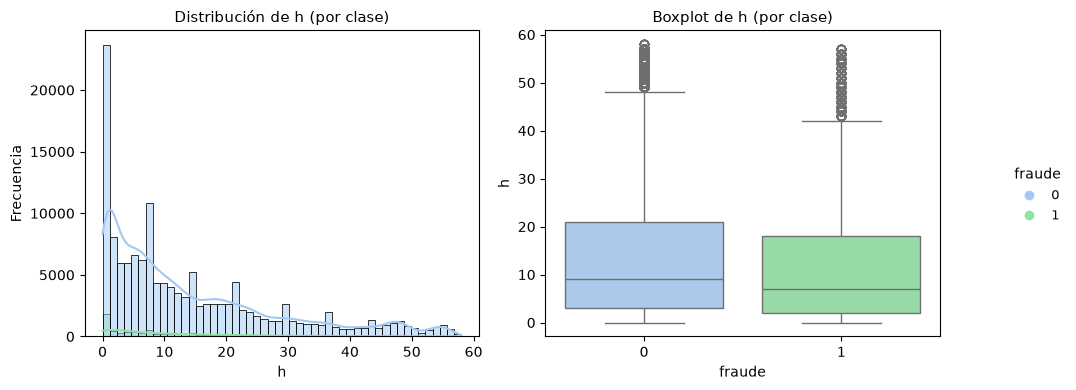

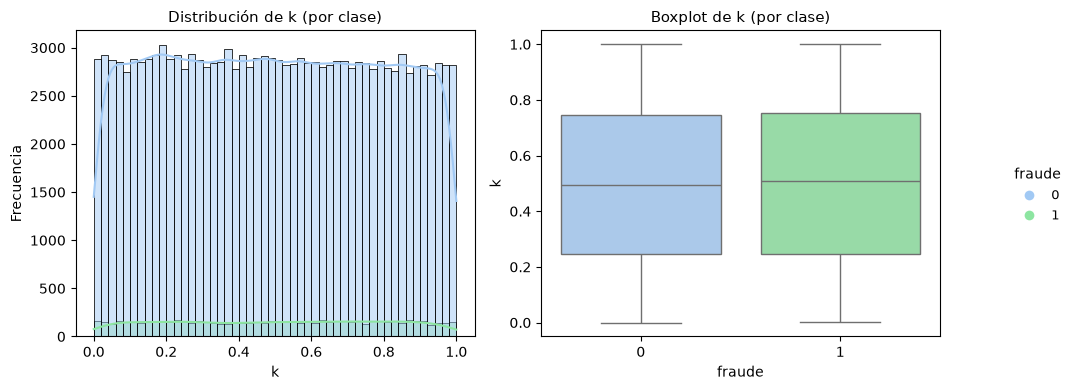

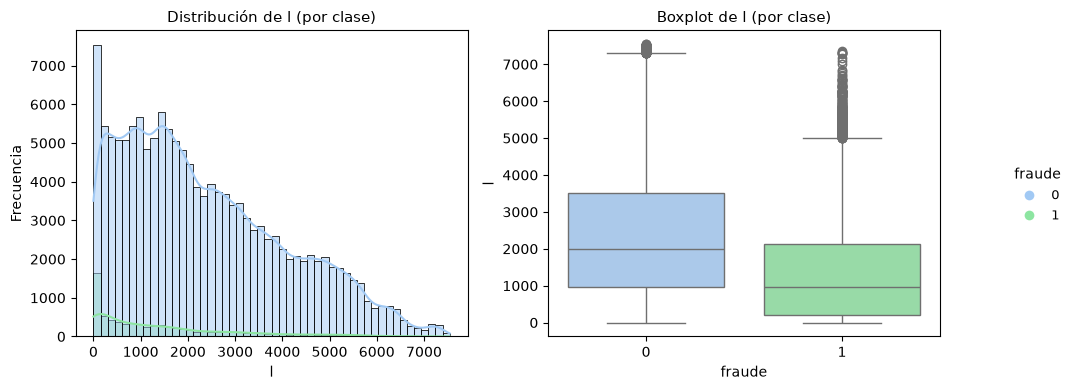

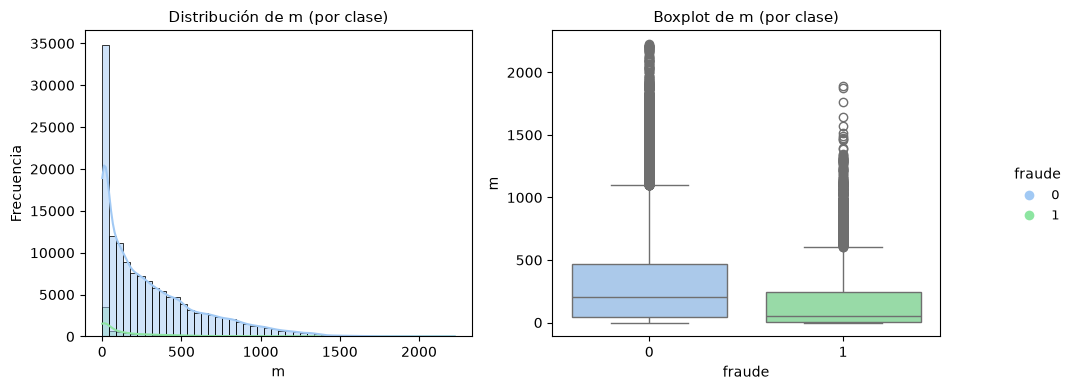

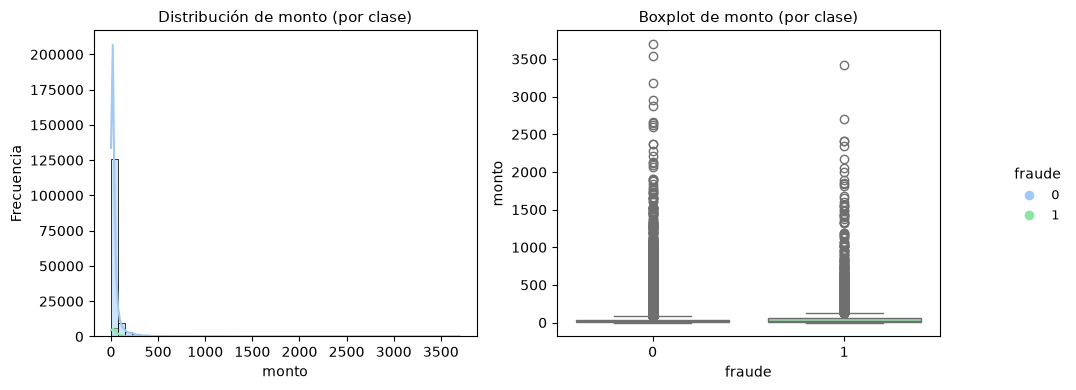

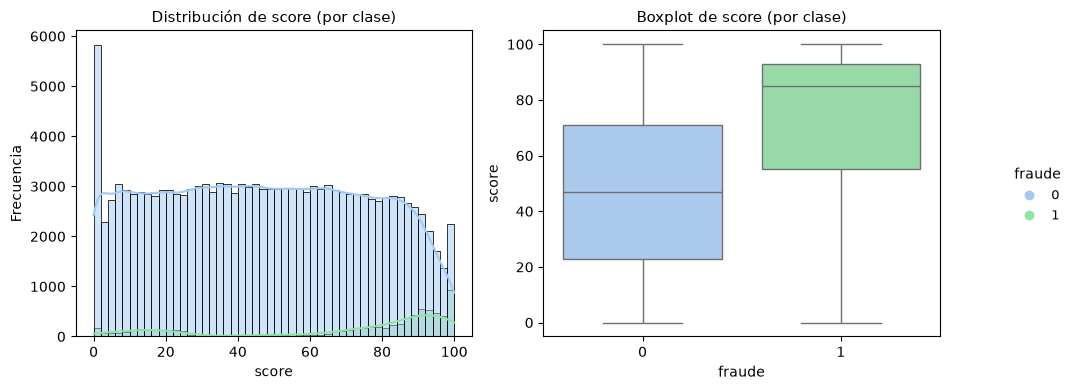

In [31]:
# 1.2 Graficar distribución y boxplot de variables numéricas (por clase) - (OPCIONAL)
target_col = 'fraude'
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 1. Histograma (Distribución y sesgo)
    sns.histplot(data=df, x=col, hue=target_col, kde=True, bins=50, ax=axes[0], palette=paleta_color)
    axes[0].set_title(f'Distribución de {col} (por clase)', size=11)
    axes[0].set_xlabel(col, size=10)
    axes[0].set_ylabel('Frecuencia', size=10)

    # 2. Boxplot (Detección de outliers)
    sns.boxplot(data=transactions, y=col, x=target_col, ax=axes[1], hue=target_col, palette=paleta_color)
    axes[1].set_title(f'Boxplot de {col} (por clase)', size=11)
    axes[1].set_xlabel(target_col, size=10)
    axes[1].set_ylabel(col, size=10)

    # Eliminar las leyendas automáticas de cada eje
    for ax in axes:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    # Crear una leyenda única con los valores del target
    target_values = sorted(transactions[target_col].dropna().unique().tolist())
    colors = dict(zip(target_values, sns.color_palette('pastel6', n_colors=len(target_values))))

    handles = [
        plt.Line2D([0], [0], linestyle='None', marker='o', markersize=7, markerfacecolor=colors[val], markeredgecolor='none', label=str(val))
        for val in target_values
    ]

    fig.subplots_adjust(right=0.82)
    fig.legend(handles=handles, title=target_col, loc='center left', bbox_to_anchor=(0.84, 0.5), frameon=False, fontsize=9)

    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()

**Observaciones:**
* `score` es la variable con mayor diferencia de % de fraude entre deciles: va de 0.33% de fraude en su decil más bajo a 21.8% en el más alto. 
* Le siguen `l`, `f` y `m`, que concentran el riesgo en su primer decil (14.4%, 11.4% y 10.3%) y decrece de forma sostenida.
* `b` y `monto` en cambio suben en el último decil (9.3% y 8.9%).
* Las barras de nulos de `b/c` (6.38%) y `d/m` (7.95%) quedan por encima de la tasa global, consistente con lo observado en el análisis de calidad.
* `k` no muestra relación con el fraude: su tasa se mantiene entre 4.68% y 5.28% en los diez deciles. Sumado a que tiene un valor distinto en cada una de las 150,000 filas y a que sus cuartiles se reparten de forma uniforme entre 0 y 1, todo apunta a un identificador o a un valor generado aleatoriamente.

**Decisión:** se descarta `k` del conjunto de variables.

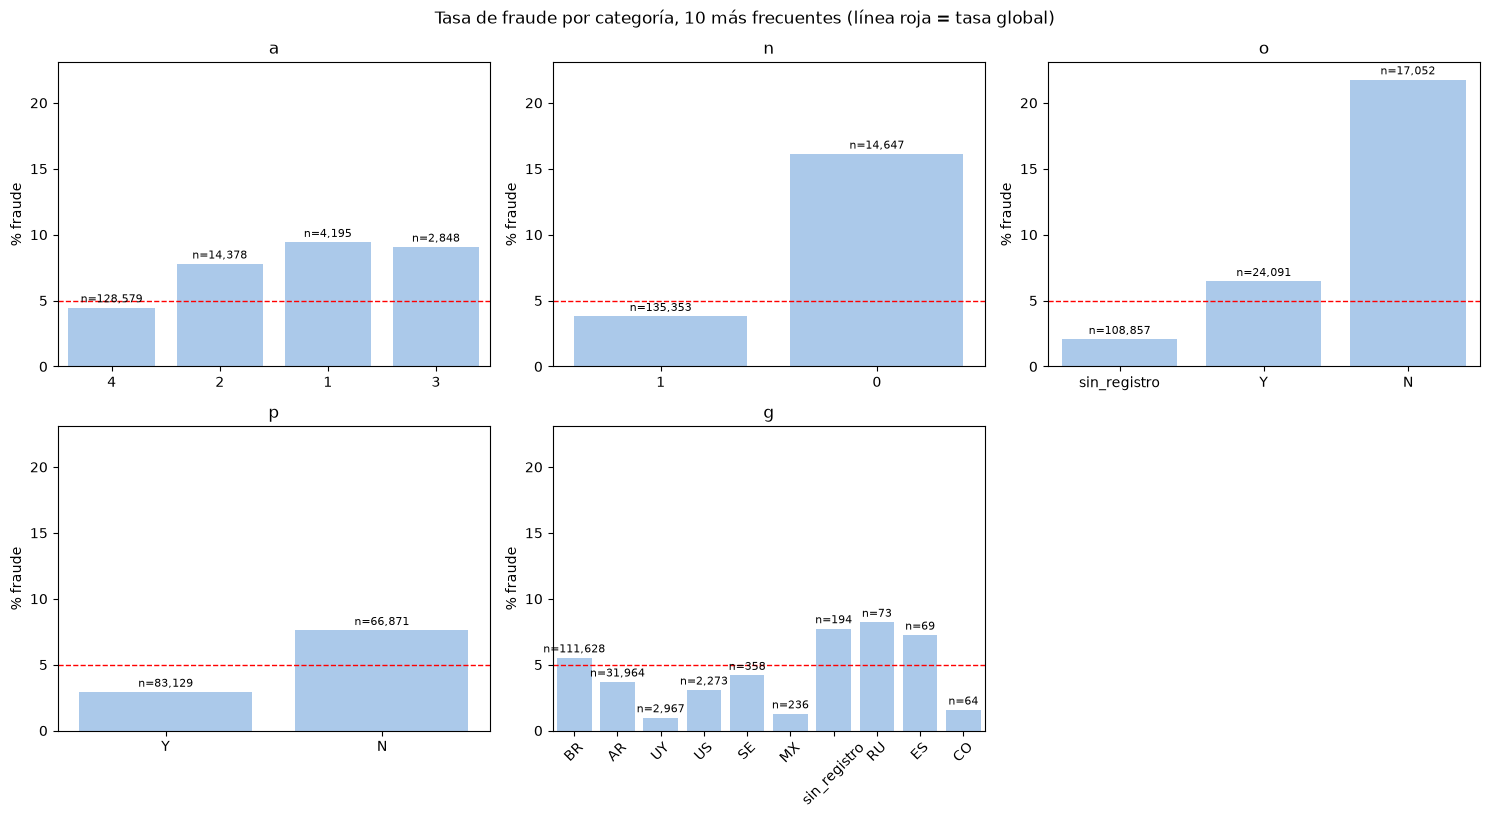

In [30]:
# 2. Tasa de fraude por categoría
cat_cols = ['a', 'n', 'o', 'p', 'g']

fig, axes = plt.subplots(2, 3, figsize=(15, 8.3))
for ax, col in zip(axes.flat, cat_cols):
    resumen = df.groupby(col, observed=True)['fraude'].agg(tasa='mean', registros='size')
    resumen = resumen.sort_values('registros', ascending=False).head(10)

    sns.barplot(x=resumen.index.astype(str), y=resumen['tasa'] * 100, ax=ax,
                color=sns.color_palette(paleta_color)[0])
    ax.axhline(tasa_global, color='red', ls='--', lw=1)
    ax.bar_label(ax.containers[0], labels=[f"n={n:,}" for n in resumen['registros']],
                 fontsize=8, padding=2)

    ax.set_title(col)
    ax.set_ylabel('% fraude')
    ax.set_xlabel('')
    ax.set_ylim(0, 21 * 1.1)
    ax.margins(y=0.15)
    if len(resumen) > 5:
        ax.tick_params(axis='x', rotation=45)

for ax in axes.flat[len(cat_cols):]:
    ax.axis('off')

fig.suptitle('Tasa de fraude por categoría, 10 más frecuentes (línea roja = tasa global)')
fig.tight_layout()


**Observaciones:**
* `n` y `o` son las categóricas con mayor diferencia entre categorías: `n = 0` tiene 16.1% de fraude sobre 14,647 registros frente a 3.8% de `n = 1`, y en `o` la tasa va de 2.05% cuando no hay registro a 21.75% en `N` (17,052 registros).
* `p` separa en la misma dirección pero con menor intensidad (7.6% en `N` contra 2.9% en `Y`), sobre volúmenes altos en ambas categorías.
* En `a` la categoría más frecuente (`4`, con el 86% de los registros) tiene 4.46% de fraude y las otras tres están entre 7.8% y 9.4%, sin seguir el orden del código. Esto confirma tratarla como nominal y no como numérica.
* En `g`, los países con tasas más altas (`RU` 8.2%, `ES` 7.2%) tienen menos de 100 registros cada uno, muy pocos para concluir; entre los volúmenes relevantes, `BR` (5.5%) está en la tasa global y `AR` (3.7%) y `UY` (1.0%) por debajo.


In [32]:
# 3. Monto por clase
display(df.groupby('fraude')['monto'].describe().round(2))

,count,mean,std,min,25%,50%,75%,max
fraude,,,,,,,,
0,142500.0,41.97,85.71,0.02,9.30,20.18,40.02,3696.35
1,7500.0,72.97,164.84,0.21,10.82,25.87,59.06,3424.81


,monto_minimo,monto_maximo,fraudes,tasa_fraude,monto_defraudado,% del monto defraudado
decil_monto,,,,,,
1,0.02,5.35,468,3.12,1768.56,0.32
2,5.36,7.83,740,4.92,4880.78,0.89
3,7.84,10.91,685,4.57,6352.70,1.16
4,10.92,14.76,597,3.97,7611.67,1.39
5,14.77,20.61,697,4.66,12112.43,2.21
6,20.62,26.84,661,4.41,15774.35,2.88
7,26.85,35.08,766,5.11,23593.87,4.31
8,35.09,48.95,694,4.63,28630.39,5.23
9,48.96,86.65,859,5.73,55296.03,10.10


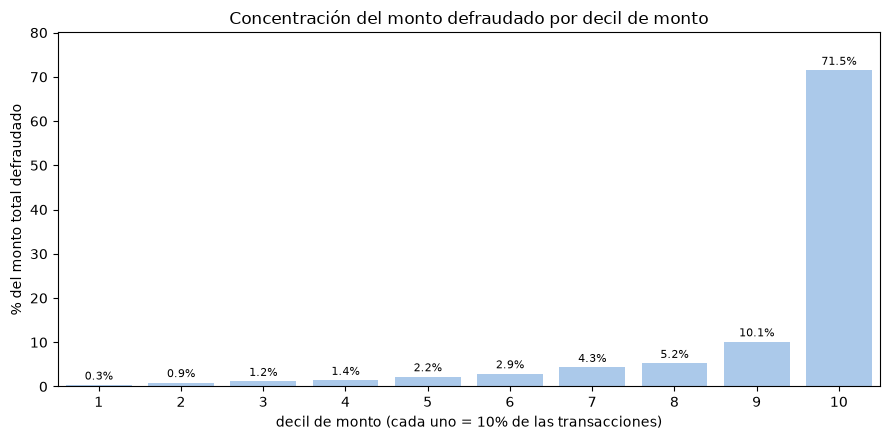

In [33]:
# 3. Concentración del monto defraudado
df['decil_monto'] = pd.qcut(df['monto'], 10, labels=False) + 1

resumen_monto = df.groupby('decil_monto').agg(
    monto_minimo=('monto', 'min'),
    monto_maximo=('monto', 'max'),
    fraudes=('fraude', 'sum'),
    tasa_fraude=('fraude', 'mean'),
)
resumen_monto['tasa_fraude'] *= 100

monto_defraudado = df[df['fraude'] == 1].groupby('decil_monto')['monto'].sum()
resumen_monto['monto_defraudado'] = monto_defraudado
resumen_monto['% del monto defraudado'] = monto_defraudado / monto_defraudado.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=resumen_monto.index, y=resumen_monto['% del monto defraudado'], ax=ax,
            color=sns.color_palette(paleta_color)[0])
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontsize=8, padding=2)
ax.set_title('Concentración del monto defraudado por decil de monto')
ax.set_xlabel('decil de monto (cada uno = 10% de las transacciones)')
ax.set_ylabel('% del monto total defraudado')
ax.margins(y=0.12)
fig.tight_layout()

display(resumen_monto.round(2))


**Observaciones:**
* El último decil de monto (transacciones de 86.67 en adelante) concentra el 71.5% de todo el monto defraudado, y los tres deciles más altos suman el 86.8%. Ese mismo decil es además el de mayor tasa de fraude (8.89% contra 5% global), así que los dos efectos se suman.
* En el extremo opuesto, los cuatro deciles más bajos reúnen 2,490 fraudes pero solo el 3.8% del monto defraudado.

**Decisión:** el desempeño del modelo se mide sobre el monto, no sobre el conteo de transacciones. Un modelo que detecte muchos fraudes pequeños y falle en los grandes puede tener buen recall y aun así no mejorar la ganancia.


In [ ]:
# Seleccionar variables categóricas
cat_cols = transactions.select_dtypes(include=['object', 'category', 'bool']).columns

for col in cat_cols:
    # Evitar graficar variables con demasiadas categorías (alta cardinalidad como IDs)
    if transactions[col].nunique() < 20:
        plt.figure(figsize=(10, 5))
        
        # Gráfico de barras agrupado por el target
        sns.countplot(data=transactions, x=col, hue=target_col, order=transactions[col].value_counts().index)
        
        plt.title(f'Frecuencia de {col} agrupado por {target_col}')
        plt.xticks(rotation=45, ha='right') # Rota las etiquetas si son muy largas
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ Se omitió '{col}' por tener alta cardinalidad ({transactions[col].nunique()} valores únicos).")